# lwtnn vs ONNX Runtime — Inference Benchmark

Compares lwtnn C++ inference against ONNX Runtime C++ on two network architectures:

| | Architecture | Type |
|---|---|---|
| **GRU** | Masking → GRU(25) → MaxoutDense(64,5) → Dense(64) → Highway(64) → Dense(4) → Softmax | Sequence |
| **MLP** | 60 → 128 → 64 → 32 → 16 → 8, tanh | Feedforward |

All timings are from C++ binaries (`lwtnn-bench-inference`, `lwtnn-bench-mlp`, `ort-bench-inference`) linked against the build in `../build/`.

In [1]:
import json
import os
import subprocess
import sys
import tarfile
import tempfile
import urllib.request
from pathlib import Path

import h5py
import numpy as np
import torch
import torch.nn as nn
import onnx
from onnx import numpy_helper, helper, TensorProto
import onnxruntime as ort
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display

REPO_ROOT = Path("../").resolve()
BUILD_DIR = REPO_ROOT / "build"
CONVERTER  = REPO_ROOT / "converters" / "keras2json.py"

LWTNN_RNN_BENCH = BUILD_DIR / "bin" / "lwtnn-bench-inference"
LWTNN_MLP_BENCH = BUILD_DIR / "bin" / "lwtnn-bench-mlp"
ORT_BENCH       = BUILD_DIR / "bin" / "ort-bench-inference"

for b in [LWTNN_RNN_BENCH, LWTNN_MLP_BENCH, ORT_BENCH]:
    assert b.exists(), f"Binary not found: {b} — run: cmake --build {BUILD_DIR}"

print("All binaries found.")

All binaries found.


In [2]:
# ── configuration ─────────────────────────────────────────────────────────────
N_INFERENCES = 2000   # per benchmark run
N_PATTERNS   = 20     # GRU sequence length (matches lwtnn-test-rnn default)
GRU_TEST_URL = "https://github.com/lwtnn/lwtnn-test-data/raw/v2.1/GRU.tgz"

# MLP architecture
MLP_LAYERS = [60, 128, 64, 32, 16, 8]
MLP_ACT    = "tanh"

## Shared utilities

In [3]:
def parse_bench_kv(text: str) -> dict:
    """Parse key=value lines from a C++ benchmark binary."""
    kv = {}
    for line in text.strip().splitlines():
        if "=" not in line:
            continue
        k, _, v = line.partition("=")
        kv[k.strip()] = v.strip()
    return kv


def run_bin(*args) -> dict:
    """Run a benchmark binary and return parsed key=value dict."""
    result = subprocess.run(
        [str(a) for a in args],
        capture_output=True, text=True, check=True,
    )
    return parse_bench_kv(result.stdout)


TIMING_KEYS = [
    ("inference_mean_us",   "Mean (µs)"),
    ("inference_min_us",    "Min (µs)"),
    ("inference_median_us", "Median (µs)"),
    ("inference_p99_us",    "p99 (µs)"),
    ("inference_max_us",    "Max (µs)"),
    ("peak_rss_kb",         "Peak RSS (MB)"),
]


def bench_to_df(cols: dict[str, dict], *, rss_to_mb=True) -> pd.DataFrame:
    """
    cols: {column_label: kv_dict}  e.g. {"lwtnn": {...}, "ORT native": {...}}
    Returns a DataFrame with metrics as rows and backends as columns.
    """
    rows = []
    for key, label in TIMING_KEYS:
        row = {"Metric": label}
        for col_name, kv in cols.items():
            val = float(kv.get(key, float("nan")))
            if rss_to_mb and key == "peak_rss_kb":
                val /= 1024.0
            row[col_name] = val
        rows.append(row)
    df = pd.DataFrame(rows).set_index("Metric")
    return df


def show_bench_df(df: pd.DataFrame, baseline_col: str | None = None):
    """Display benchmark DataFrame with optional ratio columns."""
    display_df = df.copy()
    if baseline_col and baseline_col in df.columns:
        for col in df.columns:
            if col != baseline_col:
                display_df[f"{col} / {baseline_col}"] = (df[col] / df[baseline_col]).map("{:.2f}×".format)
    display(display_df.style
            .format(lambda v: f"{v:.3f}" if isinstance(v, float) else v)
            .set_caption(f"Timing (µs) and peak RSS (MB) · {N_INFERENCES} inferences")
            .highlight_min(axis=1, subset=list(df.columns), props="font-weight:bold"))


def plot_latency_bar(df: pd.DataFrame, title: str, metric="Mean (µs)"):
    """Bar chart comparing mean latency across backends."""
    row = df.loc[metric]
    fig, ax = plt.subplots(figsize=(6, 3.5))
    colors = ["#3b82f6", "#ef4444", "#22c55e", "#f59e0b"]
    bars = ax.bar(row.index, row.values,
                  color=colors[:len(row)], width=0.5, edgecolor="white")
    ax.bar_label(bars, fmt="%.1f µs", padding=3, fontsize=9)
    ax.set_ylabel("Latency (µs)", fontsize=10)
    ax.set_title(title, fontsize=11, pad=10)
    ax.spines[["top", "right"]].set_visible(False)
    ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
    plt.tight_layout()
    plt.show()


def outputs_df(out_dict: dict) -> pd.DataFrame:
    """Format output dict as a one-row DataFrame for display."""
    return pd.DataFrame([out_dict])

---
## Part 1 — GRU network

Architecture: **Masking → GRU(25) → MaxoutDense(64, 5 pieces) → Dense(64) → Highway(64) → Dense(4) → Softmax**

Input: 19 features × 20 time-steps.  Sequence model from lwtnn's own test suite (Keras 1.x / Theano backend weights).

### 1.1  Download test data and convert to lwtnn JSON

In [4]:
gru_tmpdir = tempfile.mkdtemp(prefix="lwtnn_gru_")
gru_tmpdir = Path(gru_tmpdir)

print("Downloading GRU test data …")
tgz_path = gru_tmpdir / "GRU.tgz"
urllib.request.urlretrieve(GRU_TEST_URL, tgz_path)
with tarfile.open(tgz_path) as tar:
    tar.extractall(gru_tmpdir)

arch_json  = gru_tmpdir / "GRU.json"
variables  = gru_tmpdir / "variables.json"
h5_weights = gru_tmpdir / "weights" / "GRU_weights.h5"

with open(variables) as f:
    var_cfg = json.load(f)
class_labels = var_cfg["class_labels"]
n_gru_inputs = len(var_cfg["inputs"])
print(f"  {n_gru_inputs} input features, classes: {class_labels}")

print("Converting Keras model → lwtnn JSON …")
lwtnn_gru_json = str(gru_tmpdir / "lwtnn_model.json")
with open(lwtnn_gru_json, "w") as out_f:
    subprocess.run(
        [sys.executable, str(CONVERTER), str(arch_json), str(variables), str(h5_weights)],
        stdout=out_f, stderr=subprocess.DEVNULL, check=True,
    )
print("  done.")

  19 input features, classes: ['pu', 'pc', 'pb', 'ptau']
Converting Keras model → lwtnn JSON …


  done.


### 1.2  PyTorch reference model (Theano GRU conventions)

In [5]:
def hard_sigmoid(x):
    return torch.clamp(0.2 * x + 0.5, 0.0, 1.0)

class TheanoGRU(nn.Module):
    def __init__(self, W_z, W_r, W_h, U_z, U_r, U_h, b_z, b_r, b_h):
        super().__init__()
        for name, arr in [("W_z",W_z),("W_r",W_r),("W_h",W_h),
                          ("U_z",U_z),("U_r",U_r),("U_h",U_h),
                          ("b_z",b_z),("b_r",b_r),("b_h",b_h)]:
            self.register_buffer(name, torch.tensor(arr, dtype=torch.float32))
        self.hidden_size = W_z.shape[1]
    def forward(self, x):
        batch, seq_len, _ = x.shape
        h = torch.zeros(batch, self.hidden_size, dtype=x.dtype)
        for t in range(seq_len):
            xt = x[:, t, :]
            z  = hard_sigmoid(xt @ self.W_z + h @ self.U_z + self.b_z)
            r  = hard_sigmoid(xt @ self.W_r + h @ self.U_r + self.b_r)
            hh = torch.tanh(xt @ self.W_h + (r * h) @ self.U_h + self.b_h)
            h  = z * h + (1 - z) * hh
        return h

class MaxoutDense(nn.Module):
    def __init__(self, W, b):
        super().__init__()
        self.register_buffer("W", torch.tensor(W, dtype=torch.float32))
        self.register_buffer("b", torch.tensor(b, dtype=torch.float32))
    def forward(self, x):
        out = torch.einsum("bi,kio->bko", x, self.W) + self.b
        return out.max(dim=1).values

class Highway(nn.Module):
    def __init__(self, W, b, W_carry, b_carry):
        super().__init__()
        for name, arr in [("W",W),("b",b),("W_carry",W_carry),("b_carry",b_carry)]:
            self.register_buffer(name, torch.tensor(arr, dtype=torch.float32))
    def forward(self, x):
        t = torch.sigmoid(x @ self.W_carry + self.b_carry)
        h = torch.relu(x @ self.W + self.b)
        return t * h + (1 - t) * x

class LinearLayer(nn.Module):
    def __init__(self, W, b):
        super().__init__()
        self.register_buffer("W", torch.tensor(W, dtype=torch.float32))
        self.register_buffer("b", torch.tensor(b, dtype=torch.float32))
    def forward(self, x):
        return x @ self.W + self.b

class GRUNet(nn.Module):
    def __init__(self, h5_path):
        super().__init__()
        with h5py.File(h5_path, "r") as f:
            def w(k): return np.array(f[k])
            self.gru     = TheanoGRU(w("gru_1/gru_1_W_z"), w("gru_1/gru_1_W_r"), w("gru_1/gru_1_W_h"),
                                     w("gru_1/gru_1_U_z"), w("gru_1/gru_1_U_r"), w("gru_1/gru_1_U_h"),
                                     w("gru_1/gru_1_b_z"), w("gru_1/gru_1_b_r"), w("gru_1/gru_1_b_h"))
            self.maxout  = MaxoutDense(w("maxoutdense_1/maxoutdense_1_W"), w("maxoutdense_1/maxoutdense_1_b"))
            self.dense1  = LinearLayer(w("dense_1/dense_1_W"), w("dense_1/dense_1_b"))
            self.highway = Highway(w("highway_1/highway_1_W"), w("highway_1/highway_1_b"),
                                   w("highway_1/highway_1_W_carry"), w("highway_1/highway_1_b_carry"))
            self.dense2  = LinearLayer(w("dense_2/dense_2_W"), w("dense_2/dense_2_b"))
    def forward(self, x):
        h = self.gru(x)
        h = self.maxout(h)
        h = self.dense1(h)
        h = self.highway(h)
        h = self.dense2(h)
        return torch.softmax(h, dim=-1)

def make_gru_input(n_inputs, n_patterns):
    """2-D ramp matching lwtnn's get_values_vec."""
    x = np.linspace(-1.0, 1.0, n_inputs)
    y = np.linspace(-1.0, 1.0, n_patterns)
    return torch.tensor((x[:, None] * y[None, :]).T[None], dtype=torch.float32)  # (1, T, F)

gru_model = GRUNet(str(h5_weights)).eval()
gru_input  = make_gru_input(n_gru_inputs, N_PATTERNS)

with torch.no_grad():
    gru_pt_out = gru_model(gru_input).squeeze(0).numpy()

print("PyTorch GRU output:")
display(pd.DataFrame([dict(zip(class_labels, gru_pt_out))]).style.format("{:.6f}"))

PyTorch GRU output:


,pu,pc,pb,ptau
0,0.016547,0.003917,0.940662,0.038875


### 1.3  Build ONNX models (unrolled PyTorch export + native GRU op)

In [6]:
# ── unrolled export (Python for-loop → ~700 ONNX nodes) ───────────────────────
gru_onnx_unrolled = str(gru_tmpdir / "gru_unrolled.onnx")
torch.onnx.export(
    gru_model, gru_input, gru_onnx_unrolled,
    input_names=["normalized_input"], output_names=["class_probs"],
    dynamic_axes={"normalized_input": {0: "batch", 1: "seq_len"}},
    opset_version=17,
)
n_unrolled = len(onnx.load(gru_onnx_unrolled).graph.node)

# ── native GRU op (22 nodes, uses ORT's fused C++ GRU kernel) ─────────────────
def build_native_gru_onnx(h5_path, onnx_path):
    with h5py.File(h5_path) as f:
        def w(k): return np.array(f[k], dtype=np.float32)
        W_z,W_r,W_h = w("gru_1/gru_1_W_z"),w("gru_1/gru_1_W_r"),w("gru_1/gru_1_W_h")
        U_z,U_r,U_h = w("gru_1/gru_1_U_z"),w("gru_1/gru_1_U_r"),w("gru_1/gru_1_U_h")
        b_z,b_r,b_h = w("gru_1/gru_1_b_z"),w("gru_1/gru_1_b_r"),w("gru_1/gru_1_b_h")
        W_mo = w("maxoutdense_1/maxoutdense_1_W")
        b_mo = w("maxoutdense_1/maxoutdense_1_b")
        W_d1,b_d1 = w("dense_1/dense_1_W"),w("dense_1/dense_1_b")
        W_hw,b_hw = w("highway_1/highway_1_W"),w("highway_1/highway_1_b")
        W_hc,b_hc = w("highway_1/highway_1_W_carry"),w("highway_1/highway_1_b_carry")
        W_d2,b_d2 = w("dense_2/dense_2_W"),w("dense_2/dense_2_b")

    hidden  = W_z.shape[1]
    n_in    = W_z.shape[0]
    nb_feat = W_mo.shape[0]
    nb_out  = W_mo.shape[2]

    W_gru = np.concatenate([W_z.T,W_r.T,W_h.T], axis=0)[None]
    R_gru = np.concatenate([U_z.T,U_r.T,U_h.T], axis=0)[None]
    B_gru = np.concatenate([b_z,b_r,b_h, np.zeros(3*hidden,dtype=np.float32)])[None]
    W_mo_flat = W_mo.transpose(1,0,2).reshape(hidden, nb_feat*nb_out).astype(np.float32)

    def init(name, arr):
        return numpy_helper.from_array(np.ascontiguousarray(arr), name=name)

    inits = [
        init("gru_W",W_gru), init("gru_R",R_gru), init("gru_B",B_gru),
        init("mo_W",W_mo_flat), init("mo_b",b_mo),
        init("d1_W",W_d1), init("d1_b",b_d1),
        init("hw_W",W_hw), init("hw_b",b_hw), init("hw_Wc",W_hc), init("hw_bc",b_hc),
        init("d2_W",W_d2), init("d2_b",b_d2),
        init("ones_1",np.ones(1,dtype=np.float32)),
        init("sq_axes",np.array([0],dtype=np.int64)),
        init("mo_out_shape",np.array([1,nb_feat,nb_out],dtype=np.int64)),
    ]

    N = helper.make_node
    nodes = [
        N("Transpose",["x"],["x_seq"],perm=[1,0,2]),
        helper.make_node("GRU",["x_seq","gru_W","gru_R","gru_B"],["","gru_Yh"],
                         hidden_size=hidden, direction="forward",
                         activations=["HardSigmoid","Tanh"],
                         activation_alpha=[0.2,0.0], activation_beta=[0.5,0.0]),
        N("Squeeze",["gru_Yh","sq_axes"],["h0"]),
        N("MatMul",["h0","mo_W"],["mo_mm"]),
        N("Reshape",["mo_mm","mo_out_shape"],["mo_rs"]),
        N("Add",["mo_rs","mo_b"],["mo_add"]),
        N("ReduceMax",["mo_add"],["h1"],axes=[1],keepdims=0),
        N("MatMul",["h1","d1_W"],["d1_mm"]),
        N("Add",["d1_mm","d1_b"],["h2"]),
        N("MatMul",["h2","hw_Wc"],["hc_mm"]),
        N("Add",["hc_mm","hw_bc"],["hc_pre"]),
        N("Sigmoid",["hc_pre"],["t"]),
        N("MatMul",["h2","hw_W"],["hw_mm"]),
        N("Add",["hw_mm","hw_b"],["hw_pre"]),
        N("Relu",["hw_pre"],["h_xform"]),
        N("Mul",["t","h_xform"],["carry"]),
        N("Sub",["ones_1","t"],["one_mt"]),
        N("Mul",["one_mt","h2"],["pass"]),
        N("Add",["carry","pass"],["h3"]),
        N("MatMul",["h3","d2_W"],["d2_mm"]),
        N("Add",["d2_mm","d2_b"],["logits"]),
        N("Softmax",["logits"],["class_probs"],axis=-1),
    ]
    x_info   = helper.make_tensor_value_info("x",TensorProto.FLOAT,[1,None,n_in])
    out_info = helper.make_tensor_value_info("class_probs",TensorProto.FLOAT,[1,4])
    graph    = helper.make_graph(nodes,"gru_native_op",[x_info],[out_info],inits)
    model    = helper.make_model(graph, opset_imports=[helper.make_opsetid("",17)])
    model.ir_version = 8
    onnx.checker.check_model(model)
    onnx.save(model, onnx_path)

gru_onnx_native = str(gru_tmpdir / "gru_native.onnx")
build_native_gru_onnx(str(h5_weights), gru_onnx_native)
n_native = len(onnx.load(gru_onnx_native).graph.node)

print(f"ONNX graph size:  unrolled = {n_unrolled} nodes  |  native GRU op = {n_native} nodes")

ONNX graph size:  unrolled = 727 nodes  |  native GRU op = 22 nodes


### 1.4  Output correctness: lwtnn vs PyTorch vs ONNX

In [7]:
# lwtnn C++ single inference
lwtnn_rnn_result = subprocess.run(
    [str(REPO_ROOT / "build" / "bin" / "lwtnn-test-rnn"), lwtnn_gru_json],
    capture_output=True, text=True, check=True,
)
lwtnn_gru_out = {k: float(v) for k, v in
                 (line.split() for line in lwtnn_rnn_result.stdout.strip().splitlines())}

# ORT Python (unrolled)
sess_unrolled = ort.InferenceSession(gru_onnx_unrolled, providers=["CPUExecutionProvider"])
ort_unrolled_probs = sess_unrolled.run(["class_probs"],
    {"normalized_input": gru_input.numpy()})[0].squeeze(0)

# ORT Python (native)
sess_native = ort.InferenceSession(gru_onnx_native, providers=["CPUExecutionProvider"])
ort_native_probs = sess_native.run(["class_probs"],
    {"x": gru_input.numpy()})[0].squeeze(0)

# Build comparison table
rows = []
for i, label in enumerate(class_labels):
    lv = lwtnn_gru_out[label]
    pv = float(gru_pt_out[i])
    ov_u = float(ort_unrolled_probs[i])
    ov_n = float(ort_native_probs[i])
    rows.append({
        "Class":          label,
        "lwtnn":          lv,
        "PyTorch":        pv,
        "ORT unrolled":   ov_u,
        "ORT native GRU": ov_n,
        "|lwtnn−PyTorch|": abs(lv - pv),
        "|lwtnn−native|":  abs(lv - ov_n),
    })

gru_out_df = pd.DataFrame(rows).set_index("Class")
display(gru_out_df.style
    .format({
        "lwtnn":          "{:.7f}",
        "PyTorch":        "{:.7f}",
        "ORT unrolled":   "{:.7f}",
        "ORT native GRU": "{:.7f}",
        "|lwtnn−PyTorch|": "{:.2e}",
        "|lwtnn−native|":  "{:.2e}",
    })
    .set_caption("GRU: output comparison across backends")
    .highlight_max(subset=["|lwtnn−PyTorch|","|lwtnn−native|"],
                   props="background-color:#fee2e2"))

,lwtnn,PyTorch,ORT unrolled,ORT native GRU,|lwtnn−PyTorch|,|lwtnn−native|
Class,,,,,,
pu,0.0165469,0.0165469,0.0165469,0.0165470,3.18e-09,5.35e-08
pc,0.0039168,0.0039168,0.0039168,0.0039168,3.26e-09,4.67e-10
pb,0.9406620,0.9406618,0.9406617,0.9406615,1.52e-07,4.50e-07
ptau,0.0388746,0.0388745,0.0388746,0.0388747,7.07e-08,8.20e-08


### 1.5  C++ benchmark: lwtnn vs ORT unrolled vs ORT native GRU

In [8]:
print(f"Running {N_INFERENCES} inferences per backend …")

gru_lwtnn_kv = run_bin(LWTNN_RNN_BENCH, lwtnn_gru_json, "--n-inferences", N_INFERENCES)
print("  lwtnn done")

gru_ort_unrolled_kv = run_bin(
    ORT_BENCH, gru_onnx_unrolled,
    "--n-inferences", N_INFERENCES,
    "--n-inputs",     n_gru_inputs,
    "--n-timesteps",  N_PATTERNS,
)
print("  ORT unrolled done")

gru_ort_native_kv = run_bin(
    ORT_BENCH, gru_onnx_native,
    "--n-inferences", N_INFERENCES,
    "--n-inputs",     n_gru_inputs,
    "--n-timesteps",  N_PATTERNS,
)
print("  ORT native GRU done")

gru_bench_df = bench_to_df({
    "lwtnn":           gru_lwtnn_kv,
    "ORT unrolled":    gru_ort_unrolled_kv,
    "ORT native GRU":  gru_ort_native_kv,
})
show_bench_df(gru_bench_df, baseline_col="lwtnn")

Running 2000 inferences per backend …
  lwtnn done


  ORT unrolled done
  ORT native GRU done


,lwtnn,ORT unrolled,ORT native GRU,ORT unrolled / lwtnn,ORT native GRU / lwtnn
Metric,,,,,
Mean (µs),46.187,247.696,30.563,5.36×,0.66×
Min (µs),42.661,226.848,28.757,5.32×,0.67×
Median (µs),46.665,247.007,30.869,5.29×,0.66×
p99 (µs),49.938,270.688,34.288,5.42×,0.69×
Max (µs),64.697,317.419,46.120,4.91×,0.71×
Peak RSS (MB),15.062,35.777,33.922,2.38×,2.25×


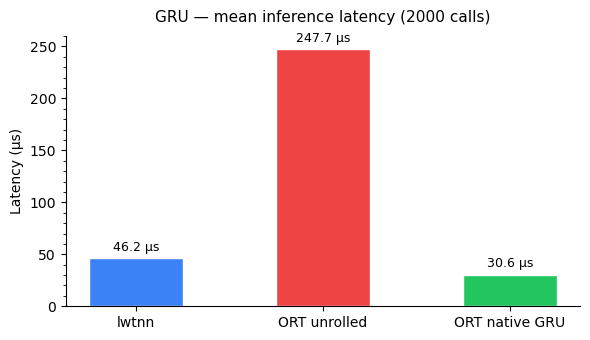

In [9]:
plot_latency_bar(gru_bench_df, f"GRU — mean inference latency ({N_INFERENCES} calls)")

---
## Part 2 — MLP network

Architecture: **60 → 128 → 64 → 32 → 16 → 8, tanh activations** (5 dense layers, feedforward).

Input: 60 features, linspace(−1, 1) ramp.  Random weights (fixed seed).

### 2.1  Build MLP and export to ONNX

In [10]:
torch.manual_seed(42)
mlp_layers = []
for in_sz, out_sz in zip(MLP_LAYERS[:-1], MLP_LAYERS[1:]):
    mlp_layers += [nn.Linear(in_sz, out_sz), nn.Tanh()]
mlp_model = nn.Sequential(*mlp_layers).eval()

n_mlp_inputs = MLP_LAYERS[0]
mlp_ramp     = torch.tensor(np.linspace(-1.0, 1.0, n_mlp_inputs), dtype=torch.float32).unsqueeze(0)

with torch.no_grad():
    mlp_pt_out = mlp_model(mlp_ramp).squeeze(0).numpy()

print(f"MLP architecture: {' → '.join(str(s) for s in MLP_LAYERS)}, {MLP_ACT}")
print("PyTorch output:")
display(pd.DataFrame([{f"out_{i}": float(v) for i, v in enumerate(mlp_pt_out)}])
        .style.format("{:.6f}"))

# Export to ONNX
mlp_tmpdir   = Path(tempfile.mkdtemp(prefix="lwtnn_mlp_"))
mlp_onnx     = str(mlp_tmpdir / "mlp.onnx")
torch.onnx.export(
    mlp_model, mlp_ramp, mlp_onnx,
    input_names=["input"], output_names=["output"],
    opset_version=17,
    dynamic_axes={"input": {0: "batch"}, "output": {0: "batch"}},
)
n_mlp_nodes = len(onnx.load(mlp_onnx).graph.node)
print(f"ONNX graph: {n_mlp_nodes} nodes")

MLP architecture: 60 → 128 → 64 → 32 → 16 → 8, tanh
PyTorch output:


,out_0,out_1,out_2,out_3,out_4,out_5,out_6,out_7
0,0.258992,-0.067616,-0.130744,0.002533,-0.127779,0.226334,-0.126954,0.184915


ONNX graph: 10 nodes


### 2.2  Write lwtnn JSON

In [11]:
def write_mlp_lwtnn_json(model, path):
    inputs_json = [{"name": f"in_{i}", "offset": 0.0, "scale": 1.0}
                   for i in range(MLP_LAYERS[0])]
    layers_json = []
    for module in model:
        if isinstance(module, nn.Linear):
            W = module.weight.detach().numpy()
            b = module.bias.detach().numpy()
            layers_json.append({
                "architecture": "dense",
                "activation":   MLP_ACT,
                "weights":      W.flatten().tolist(),
                "bias":         b.tolist(),
            })
    outputs_json = [f"out_{i}" for i in range(MLP_LAYERS[-1])]
    with open(path, "w") as f:
        json.dump({"inputs": inputs_json, "layers": layers_json, "outputs": outputs_json}, f)

mlp_lwtnn_json = str(mlp_tmpdir / "mlp_lwtnn.json")
write_mlp_lwtnn_json(mlp_model, mlp_lwtnn_json)
print(f"lwtnn JSON written: {mlp_lwtnn_json}")

lwtnn JSON written: /tmp/lwtnn_mlp_xx68974l/mlp_lwtnn.json


### 2.3  Output correctness: lwtnn vs PyTorch vs ONNX

In [12]:
# lwtnn C++ single forward pass
mlp_lwtnn_kv_single = run_bin(LWTNN_MLP_BENCH, mlp_lwtnn_json, "--n-inferences", 1)
mlp_lwtnn_outputs = {}
for pair in mlp_lwtnn_kv_single.get("outputs", "").split():
    k, _, v = pair.partition("=")
    mlp_lwtnn_outputs[k] = float(v)

# ORT Python
sess_mlp = ort.InferenceSession(mlp_onnx, providers=["CPUExecutionProvider"])
ort_mlp_out = sess_mlp.run(None, {"input": mlp_ramp.numpy()})[0].squeeze(0)

# Comparison table
mlp_rows = []
for i in range(MLP_LAYERS[-1]):
    k   = f"out_{i}"
    lv  = mlp_lwtnn_outputs.get(k, float("nan"))
    pv  = float(mlp_pt_out[i])
    ov  = float(ort_mlp_out[i])
    mlp_rows.append({
        "Output":         k,
        "lwtnn":          lv,
        "PyTorch":        pv,
        "ORT (ONNX)":     ov,
        "|lwtnn−PyTorch|": abs(lv - pv),
        "|lwtnn−ORT|":    abs(lv - ov),
    })

mlp_out_df = pd.DataFrame(mlp_rows).set_index("Output")
display(mlp_out_df.style
    .format({
        "lwtnn":          "{:.7f}",
        "PyTorch":        "{:.7f}",
        "ORT (ONNX)":     "{:.7f}",
        "|lwtnn−PyTorch|": "{:.2e}",
        "|lwtnn−ORT|":    "{:.2e}",
    })
    .set_caption("MLP: output comparison across backends")
    .highlight_max(subset=["|lwtnn−PyTorch|","|lwtnn−ORT|"],
                   props="background-color:#fee2e2"))

,lwtnn,PyTorch,ORT (ONNX),|lwtnn−PyTorch|,|lwtnn−ORT|
Output,,,,,
out_0,0.2589920,0.2589920,0.2589920,1.63e-08,4.33e-08
out_1,-0.0676160,-0.0676156,-0.0676156,3.57e-07,3.72e-07
out_2,-0.1307440,-0.1307444,-0.1307444,3.68e-07,3.53e-07
out_3,0.0025330,0.0025332,0.0025332,2.18e-07,2.18e-07
out_4,-0.1277790,-0.1277794,-0.1277793,3.65e-07,3.35e-07
out_5,0.2263340,0.2263340,0.2263340,3.54e-08,9.31e-09
out_6,-0.1269540,-0.1269535,-0.1269535,4.73e-07,4.88e-07
out_7,0.1849150,0.1849152,0.1849152,1.55e-07,1.70e-07


### 2.4  C++ benchmark: lwtnn vs ORT

In [13]:
print(f"Running {N_INFERENCES} inferences per backend …")

mlp_lwtnn_kv = run_bin(LWTNN_MLP_BENCH, mlp_lwtnn_json, "--n-inferences", N_INFERENCES)
print("  lwtnn done")

mlp_ort_kv = run_bin(
    ORT_BENCH, mlp_onnx,
    "--n-inferences", N_INFERENCES,
    "--n-inputs",     n_mlp_inputs,
)
print("  ORT done")

mlp_bench_df = bench_to_df({
    "lwtnn":      mlp_lwtnn_kv,
    "ORT (ONNX)": mlp_ort_kv,
})
show_bench_df(mlp_bench_df, baseline_col="lwtnn")

Running 2000 inferences per backend …


  lwtnn done


  ORT done


,lwtnn,ORT (ONNX),ORT (ONNX) / lwtnn
Metric,,,
Mean (µs),10.067,4.586,0.46×
Min (µs),9.682,4.399,0.45×
Median (µs),9.783,4.477,0.46×
p99 (µs),12.919,6.106,0.47×
Max (µs),26.218,20.213,0.77×
Peak RSS (MB),13.070,33.812,2.59×


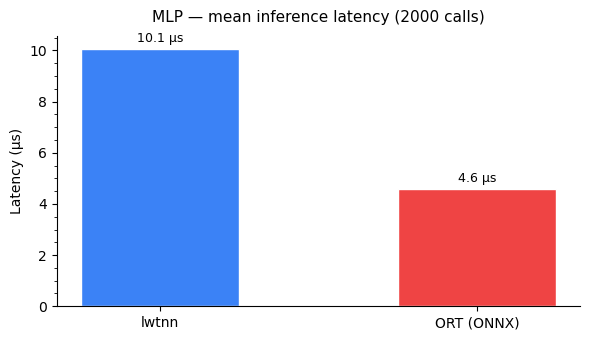

In [14]:
plot_latency_bar(mlp_bench_df, f"MLP — mean inference latency ({N_INFERENCES} calls)")

---
## Summary — GRU vs MLP, lwtnn vs ORT

In [15]:
summary_rows = [
    {"Model": "GRU (19f × 20t)",  "Backend": "lwtnn",          "Mean (µs)": float(gru_lwtnn_kv["inference_mean_us"]),      "Peak RSS (MB)": float(gru_lwtnn_kv["peak_rss_kb"])/1024},
    {"Model": "GRU (19f × 20t)",  "Backend": "ORT unrolled",   "Mean (µs)": float(gru_ort_unrolled_kv["inference_mean_us"]), "Peak RSS (MB)": float(gru_ort_unrolled_kv["peak_rss_kb"])/1024},
    {"Model": "GRU (19f × 20t)",  "Backend": "ORT native GRU", "Mean (µs)": float(gru_ort_native_kv["inference_mean_us"]),  "Peak RSS (MB)": float(gru_ort_native_kv["peak_rss_kb"])/1024},
    {"Model": "MLP (60→…→8)",    "Backend": "lwtnn",          "Mean (µs)": float(mlp_lwtnn_kv["inference_mean_us"]),        "Peak RSS (MB)": float(mlp_lwtnn_kv["peak_rss_kb"])/1024},
    {"Model": "MLP (60→…→8)",    "Backend": "ORT (ONNX)",     "Mean (µs)": float(mlp_ort_kv["inference_mean_us"]),          "Peak RSS (MB)": float(mlp_ort_kv["peak_rss_kb"])/1024},
]
summary_df = pd.DataFrame(summary_rows).set_index(["Model", "Backend"])
display(summary_df.style
        .format({"Mean (µs)": "{:.2f}", "Peak RSS (MB)": "{:.1f}"})
        .set_caption("Summary — mean latency and peak memory")
        .highlight_min(axis=0, subset=["Mean (µs)", "Peak RSS (MB)"], props="font-weight:bold"))

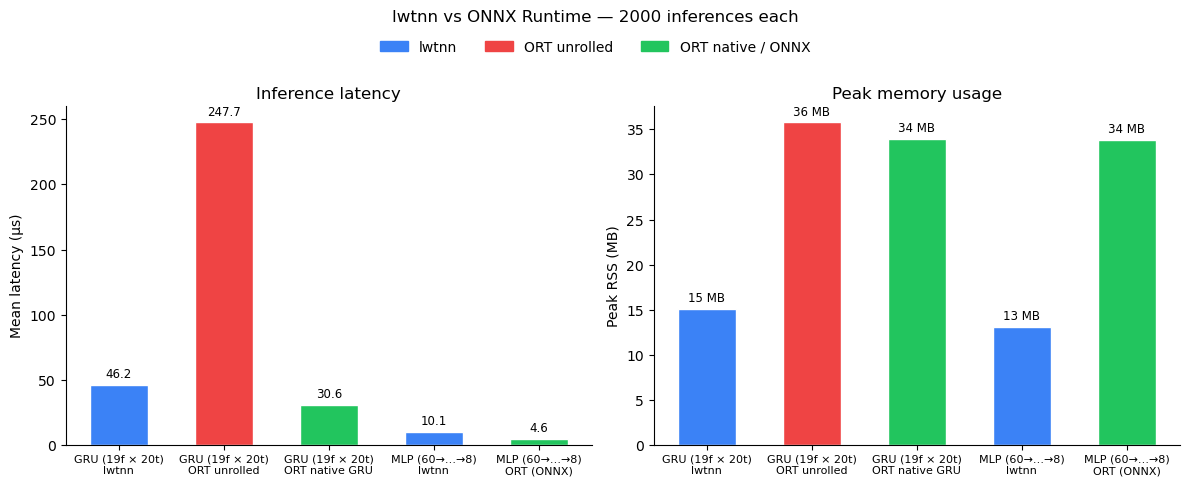

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# ── latency panel ──────────────────────────────────────────────────────────────
ax = axes[0]
models   = [r["Model"]   for r in summary_rows]
backends = [r["Backend"] for r in summary_rows]
latency  = [r["Mean (µs)"] for r in summary_rows]
labels   = [f"{m}\n{b}" for m, b in zip(models, backends)]
colors = ["#3b82f6", "#ef4444", "#22c55e", "#3b82f6", "#22c55e"]
bars = ax.bar(range(len(summary_rows)), latency, color=colors, width=0.55, edgecolor="white")
ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=8.5)
ax.set_xticks(range(len(summary_rows)))
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel("Mean latency (µs)")
ax.set_title("Inference latency")
ax.spines[["top", "right"]].set_visible(False)

# ── memory panel ──────────────────────────────────────────────────────────────
ax2 = axes[1]
rss = [r["Peak RSS (MB)"] for r in summary_rows]
bars2 = ax2.bar(range(len(summary_rows)), rss, color=colors, width=0.55, edgecolor="white")
ax2.bar_label(bars2, fmt="%.0f MB", padding=3, fontsize=8.5)
ax2.set_xticks(range(len(summary_rows)))
ax2.set_xticklabels(labels, fontsize=8)
ax2.set_ylabel("Peak RSS (MB)")
ax2.set_title("Peak memory usage")
ax2.spines[["top", "right"]].set_visible(False)

# legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(color="#3b82f6", label="lwtnn"),
    Patch(color="#ef4444", label="ORT unrolled"),
    Patch(color="#22c55e", label="ORT native / ONNX"),
]
fig.legend(handles=legend_elements, loc="upper center", ncol=3,
           bbox_to_anchor=(0.5, 1.03), frameon=False)
plt.suptitle(f"lwtnn vs ONNX Runtime — {N_INFERENCES} inferences each",
             y=1.07, fontsize=12)
plt.tight_layout()
plt.show()

In [17]:
# cleanup temp dirs
import shutil
shutil.rmtree(gru_tmpdir, ignore_errors=True)
shutil.rmtree(mlp_tmpdir, ignore_errors=True)
print("Temp files cleaned up.")

Temp files cleaned up.
